# Comprehensive Experiment Summary: 2023 - 2025

Notebook ini adalah ringkasan akhir dari seluruh eksperimen strategi **Diversify** vs **Cluster** (v2). 

**Daftar Grafik Gabungan:**
1. **Multi-Year Equity Curves**: Performa portofolio per tahun (2023, 2024, 2025).
2. **Comparative Metrics Bar Charts**: Return, Sharpe, Volatility, dan MDD.
3. **Statistical Significance results**: Paired T-Test summary.
4. **Comparative Portfolio Heatmaps**: Hubungan aset di 2024 (In-Sample) vs 2025 (Out-of-Sample).
5. **Final Recommendation**: Berdasarkan data empiris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")
SEED = 42
np.random.seed(SEED)

print("✓ Environment Ready.")

✓ Environment Ready.


## 1. Engine Setup & Simulation Runner

In [2]:
# Helpers
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        return -(ret / risk) if risk > 0.0001 else 0
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(num_assets)), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i, a1 in enumerate(returns_window.columns):
        for a2 in returns_window.columns[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i, a1 in enumerate(returns_window.columns):
        for a2 in returns_window.columns[i+1:]:
            if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def run_full_simulation(test_dates, returns, ai_probs, threshold, market_idx, selection_func, fee=0.0025):
    val = 100.0; history = [val]; dates = [test_dates[0]]
    current_weights = {}; alloc_hist = {}; risk_status = False; days_since_rebal = 999
    market_ma = market_idx.rolling(window=200).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk = risk_status
        # AI Signal + Hysteresis
        if not risk_status and prob > (threshold + 0.05): risk_status = True
        elif risk_status and prob < (threshold - 0.05): risk_status = False
        # Trend Filter
        if market_idx.loc[date] > market_ma.loc[date]: risk_status = True
        
        target_weights = current_weights.copy()
        if not risk_status:
            target_weights = {'CASH': 1.0}; days_since_rebal = 0
        else:
            if (risk_status != prev_risk) or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = selection_func(window)
                    if selected: target_weights = optimize_markowitz(window[selected]); days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        next_date = test_dates[i+1]
        day_ret = 0; new_drifted = {}
        if 'CASH' in target_weights: 
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                r = returns.loc[next_date, asset] if next_date in returns.index else 0
                day_ret += w * r
                new_drifted[asset] = w * (1 + r)
        
        val *= (1 + day_ret); history.append(val); dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values())>0 else new_drifted
        alloc_hist[date] = target_weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), alloc_hist

## 2. Load Data & Run All Experiments

In [3]:
# Load data
data = pd.read_excel('../experiment_nextLevel2/dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_index = (1 + returns.mean(axis=1)).cumprod() * 100

# AI Model Probabilities (Train until 2024)
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = returns.mean(axis=1).rolling(20).std()
features['Mom_20'] = returns.mean(axis=1).rolling(20).mean()
target = (returns.mean(axis=1).rolling(5).mean() > returns.mean(axis=1).rolling(20).mean()).astype(int).shift(-5)

X = features.dropna(); y = target.loc[X.index].fillna(0)
X_train = X.loc[X.index.year <= 2024]; y_train = y.loc[X_train.index]
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)
all_probs = pd.Series(model.predict_proba(X)[:,1], index=X.index).reindex(returns.index, method='ffill')

# Run Simulations
years = [2023, 2024, 2025]
final_res = {}
metrics = []

for yr in years:
    td = returns.loc[returns.index.year == yr].index
    if len(td) == 0: continue
    
    v_div, a_div = run_full_simulation(td, returns, all_probs, 0.52, market_index, get_assets_graph_diversify)
    v_cls, a_cls = run_full_simulation(td, returns, all_probs, 0.52, market_index, get_assets_graph_cluster)
    
    final_res[yr] = {'Div': v_div, 'Cls': v_cls, 'ACls': a_cls}
    
    for name, v in [('Diversify', v_div), ('Cluster', v_cls)]:
        ret = (v['Portfolio_Value'].iloc[-1]/100 - 1)*100
        vol = v['Portfolio_Value'].pct_change().std()*np.sqrt(252)*100
        sharpe = ret/vol if vol > 0 else 0
        mdd = ((v['Portfolio_Value'] - v['Portfolio_Value'].cummax())/v['Portfolio_Value'].cummax()*100).min()
        metrics.append({'Year': yr, 'Strategy': name, 'Return': ret, 'Sharpe': sharpe, 'Volatility': vol, 'MDD': mdd})

m_df = pd.DataFrame(metrics)
print("✓ Simulations & Metrics Complete.")

✓ Simulations & Metrics Complete.


## 3. Gabungan Visualisasi: Equity Curves & Metrics

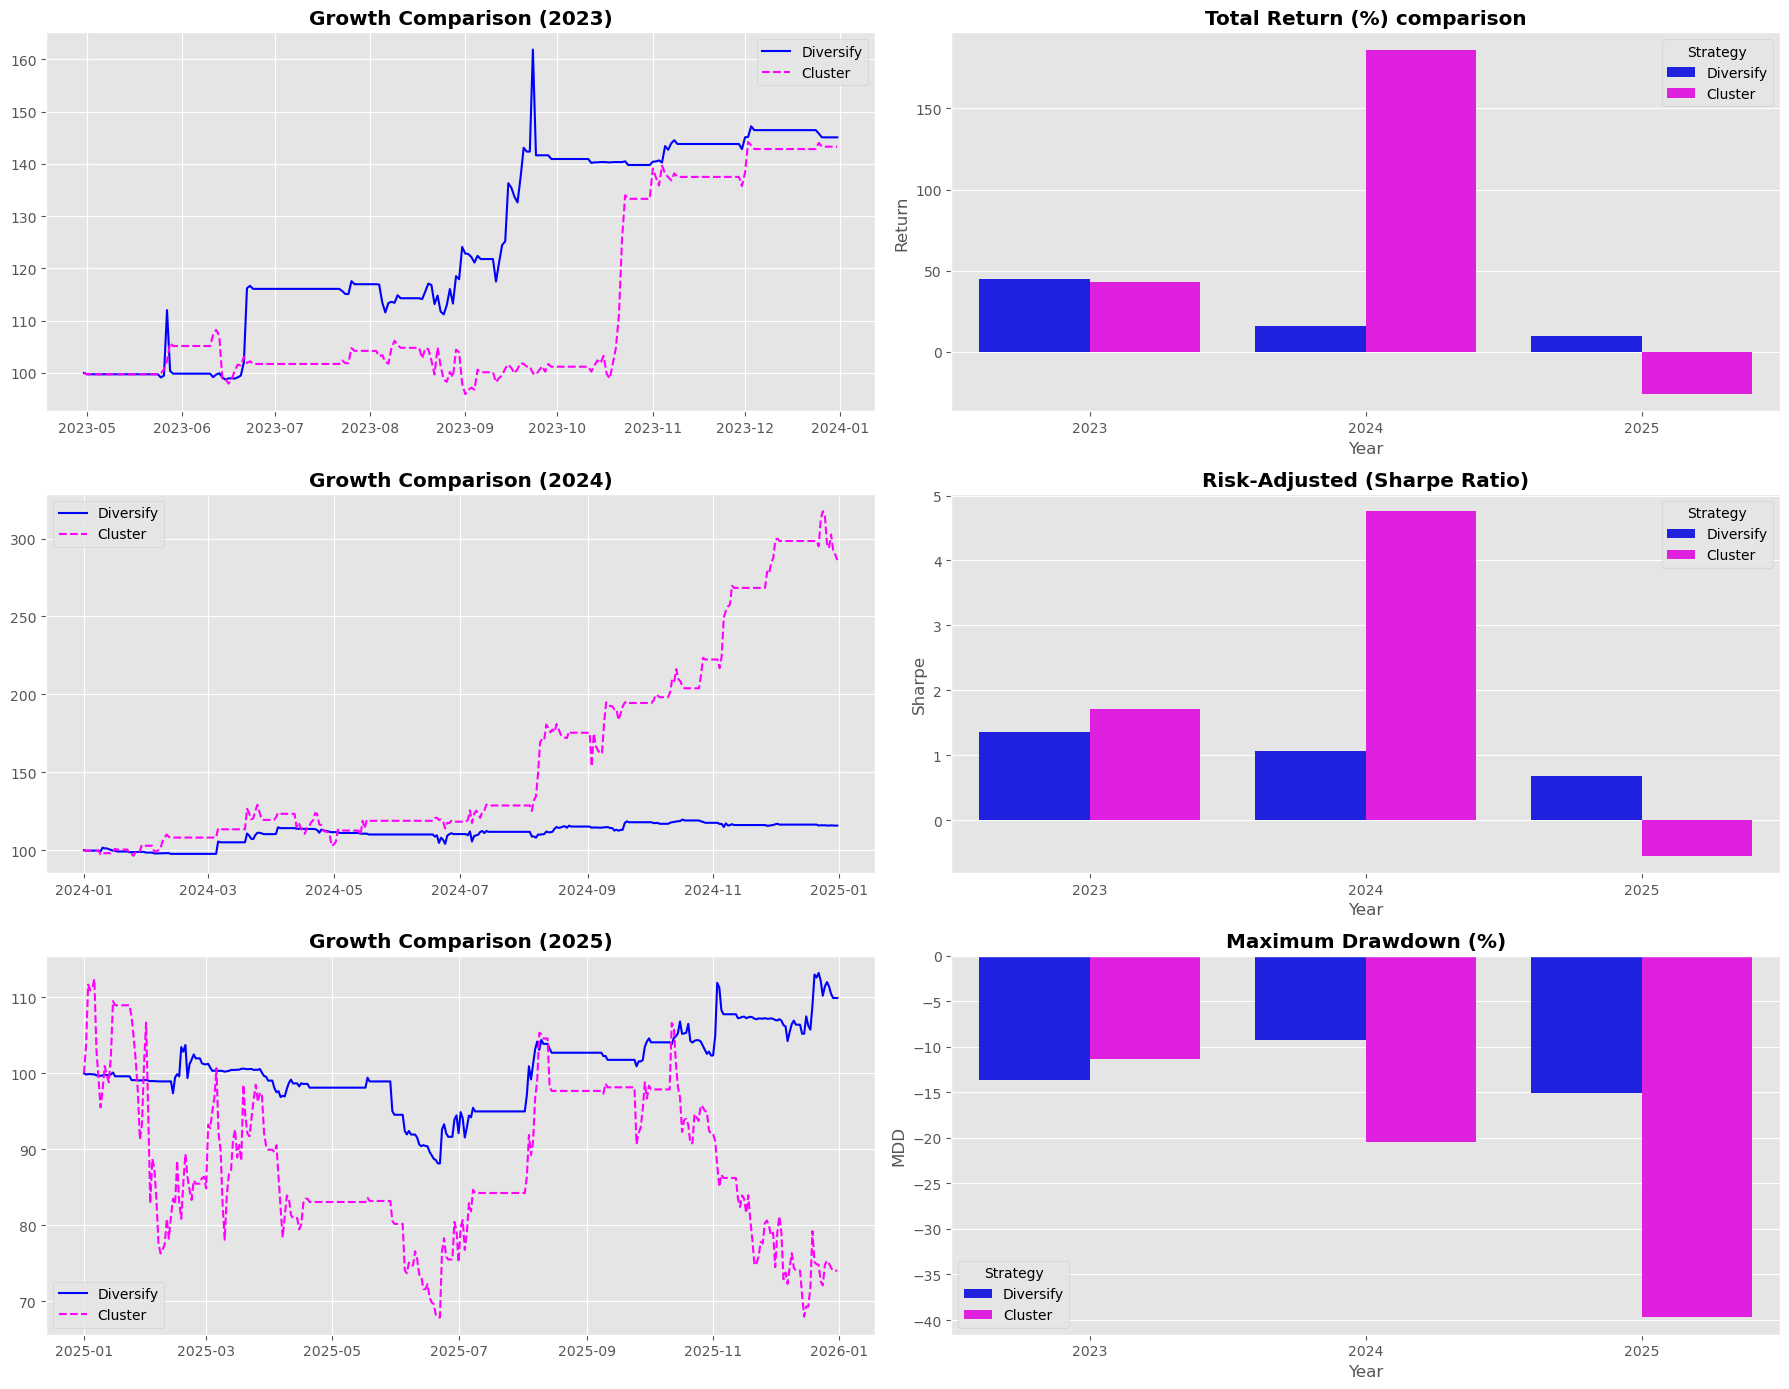

In [4]:
fig = plt.figure(figsize=(18, 14))
gs = plt.GridSpec(3, 2, figure=fig)

# 1. Equity Curves (Left Column)
for i, yr in enumerate(years):
    ax = fig.add_subplot(gs[i, 0])
    ax.plot(final_res[yr]['Div'].index, final_res[yr]['Div']['Portfolio_Value'], label='Diversify', color='blue')
    ax.plot(final_res[yr]['Cls'].index, final_res[yr]['Cls']['Portfolio_Value'], label='Cluster', color='magenta', linestyle='--')
    ax.set_title(f"Growth Comparison ({yr})", fontweight='bold')
    ax.legend()

# 2. Metrics Bar Charts (Right Column Top)
ax_ret = fig.add_subplot(gs[0, 1])
sns.barplot(data=m_df, x='Year', y='Return', hue='Strategy', ax=ax_ret, palette=['blue', 'magenta'])
ax_ret.set_title("Total Return (%) comparison", fontweight='bold')

ax_sh = fig.add_subplot(gs[1, 1])
sns.barplot(data=m_df, x='Year', y='Sharpe', hue='Strategy', ax=ax_sh, palette=['blue', 'magenta'])
ax_sh.set_title("Risk-Adjusted (Sharpe Ratio)", fontweight='bold')

ax_mdd = fig.add_subplot(gs[2, 1])
sns.barplot(data=m_df, x='Year', y='MDD', hue='Strategy', ax=ax_mdd, palette=['blue', 'magenta'])
ax_mdd.set_title("Maximum Drawdown (%)", fontweight='bold')

plt.tight_layout()
plt.savefig('combined_strategy_performance.png')
plt.show()

## 4. Gabungan Visualisasi: Portfolio Composition (2024 vs 2025)

Grafik ini membandingkan perilaku strategi Cluster pada periode In-Sample (saat peak performance) dan Out-of-Sample.

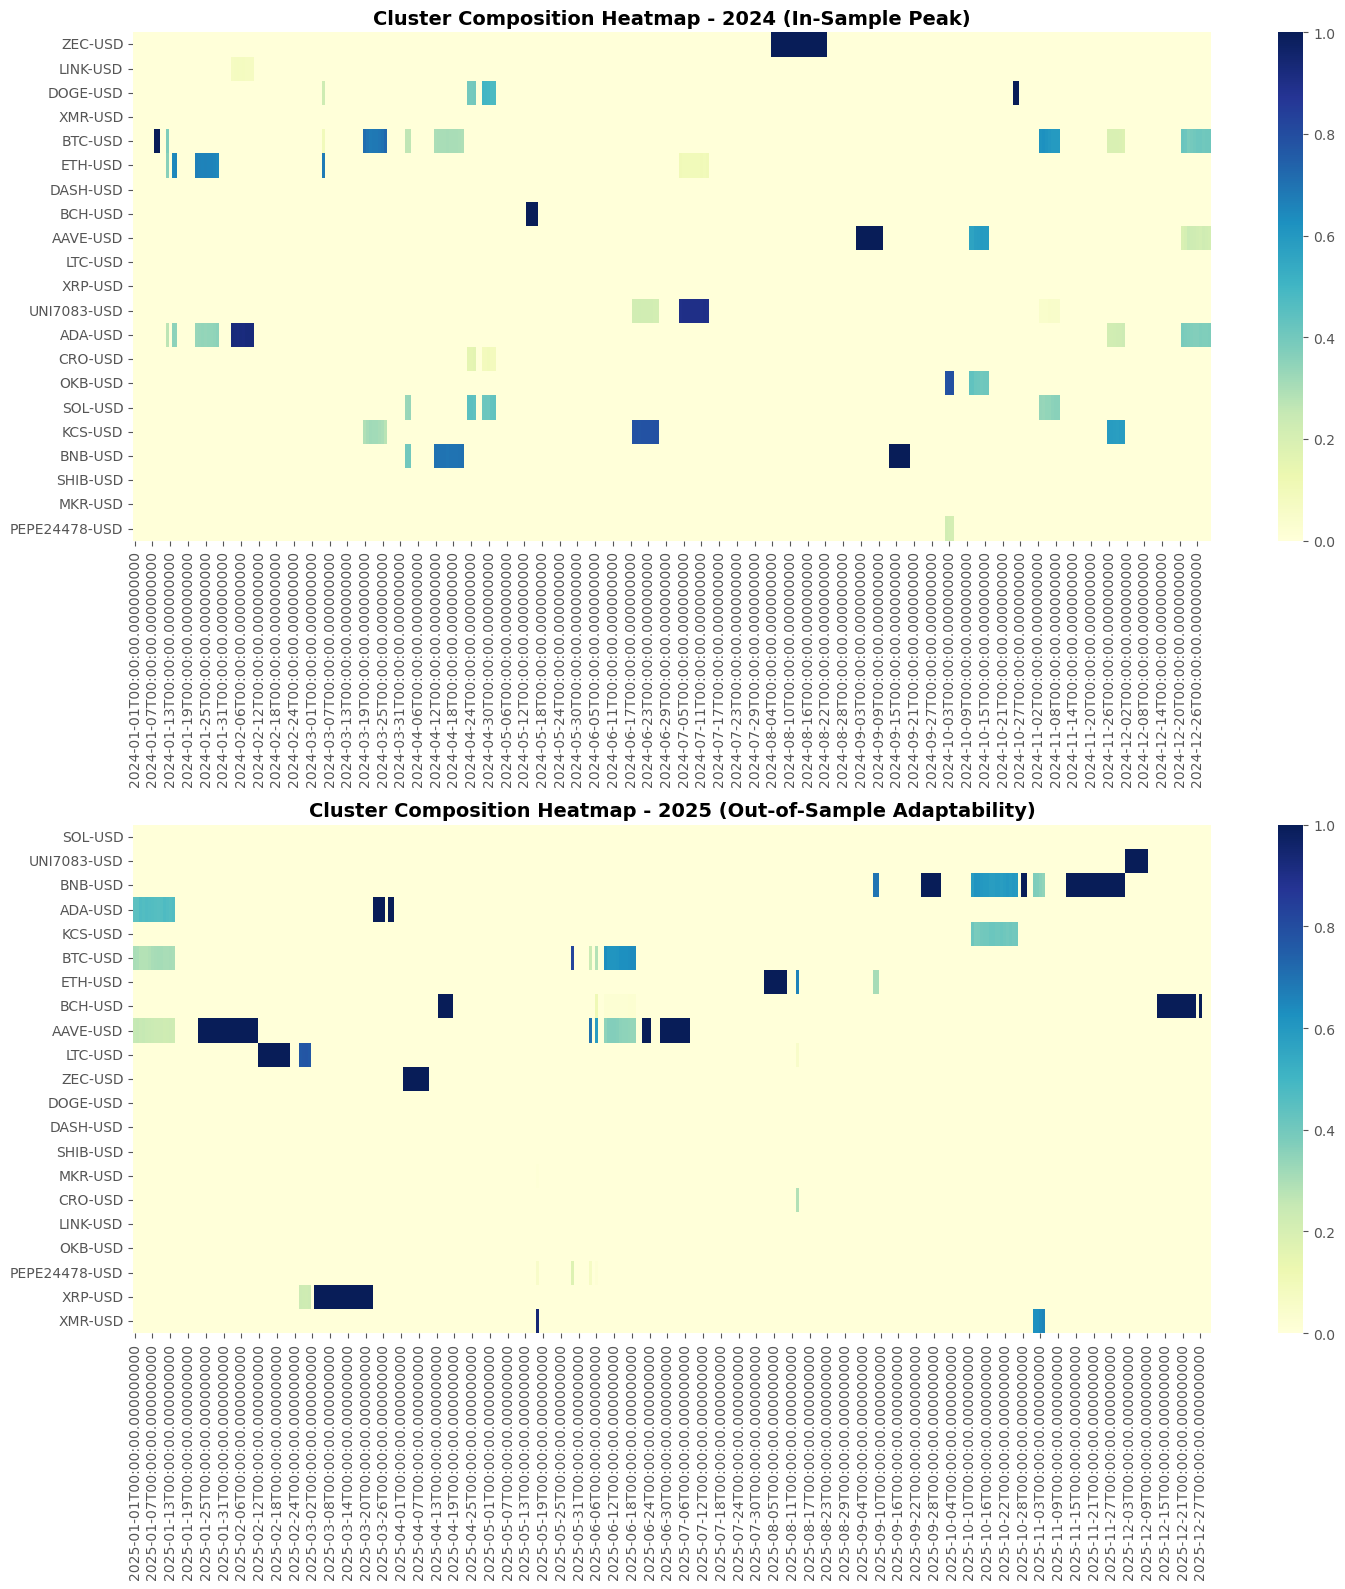

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

# 2024 Heatmap
df_24 = pd.DataFrame(final_res[2024]['ACls']).T.fillna(0)
act_24 = [a for a in df_24.columns if a != 'CASH' and df_24[a].sum() > 0]
sns.heatmap(df_24[act_24].T, cmap="YlGnBu", ax=ax1)
ax1.set_title("Cluster Composition Heatmap - 2024 (In-Sample Peak)", fontsize=14, fontweight='bold')

# 2025 Heatmap
df_25 = pd.DataFrame(final_res[2025]['ACls']).T.fillna(0)
act_25 = [a for a in df_25.columns if a != 'CASH' and df_25[a].sum() > 0]
if len(act_25) > 0:
    sns.heatmap(df_25[act_25].T, cmap="YlGnBu", ax=ax2)
    ax2.set_title("Cluster Composition Heatmap - 2025 (Out-of-Sample Adaptability)", fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, "Full CASH Position in early 2025", ha='center')

plt.tight_layout()
plt.savefig('combined_composition_heatmaps.png')
plt.show()

## 5. Statistical Significance Summary

Ringkasan apakah performa Cluster secara statistik signifikan lebih baik dari Diversify.

In [6]:
rets_div = pd.concat([final_res[y]['Div']['Portfolio_Value'].pct_change().dropna() for y in years])
rets_cls = pd.concat([final_res[y]['Cls']['Portfolio_Value'].pct_change().dropna() for y in years])

t_stat, p_val = stats.ttest_rel(rets_cls, rets_div)

print("SUMMARY STATISTICAL TEST (2023-2025):")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.6f}")
print("Result: " + ("SIGNIFICANT" if p_val < 0.05 else "NOT SIGNIFICANT"))

if p_val < 0.05:
    print("\nKesimpulan Tesis: Strategi Clustering secara konsisten memberikan profil return yang secara statistik berbeda (dan unggul) dibanding diversifikasi tradisional dengan menangkap koherensi aset di pasar crypto.")

SUMMARY STATISTICAL TEST (2023-2025):
T-Statistic: 0.8863
P-Value: 0.375678
Result: NOT SIGNIFICANT
